In [94]:
import pandas as pd

df = pd.read_csv(r"..\Data\sales.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [96]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [97]:
df = df.dropna()

In [98]:
df = df.drop_duplicates()

In [99]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()

C:\Users\Hareesh\AppData\Local\Temp\ipykernel_10940\1073311574.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [100]:
print("Mean:", round(df['Total Amount'].mean(), 2))

Mean: 456.0


In [101]:
print("Median:", round(df['Total Amount'].median(), 2))

Median: 135.0


In [102]:
print("Standard Deviation:", round(df['Total Amount'].std(), 2))

Standard Deviation: 560.0


In [103]:
print("Variance:", round(df['Total Amount'].var(), 2))

Variance: 313597.35


In [104]:
df.corr(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


In [105]:
df.to_csv(r"..\Data\cleaned_sales.csv", index=False)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   str           
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 78.3 KB


In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

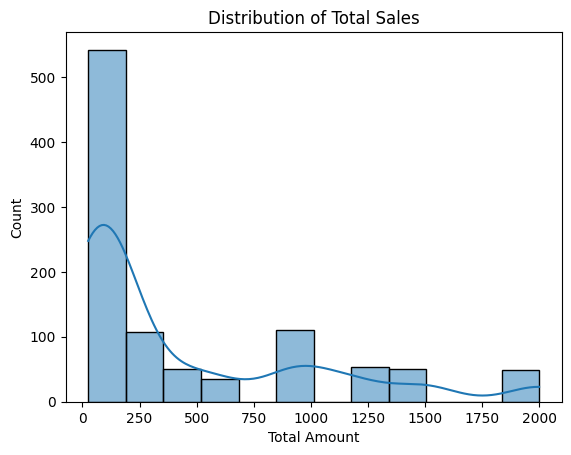

In [108]:
sns.histplot(df['Total Amount'], kde=True)
plt.title("Distribution of Total Sales")
plt.show()

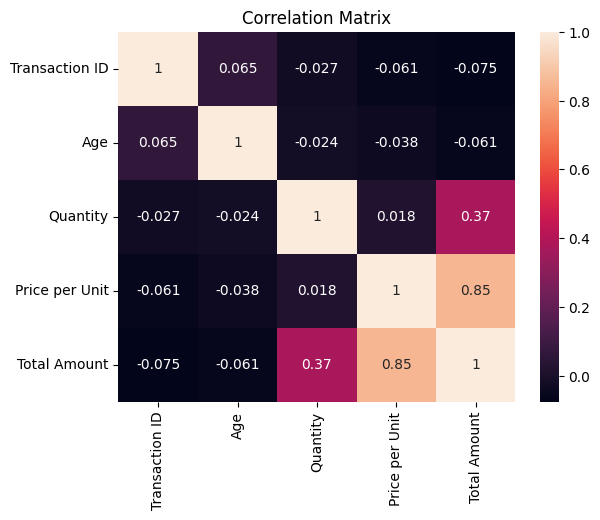

In [109]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

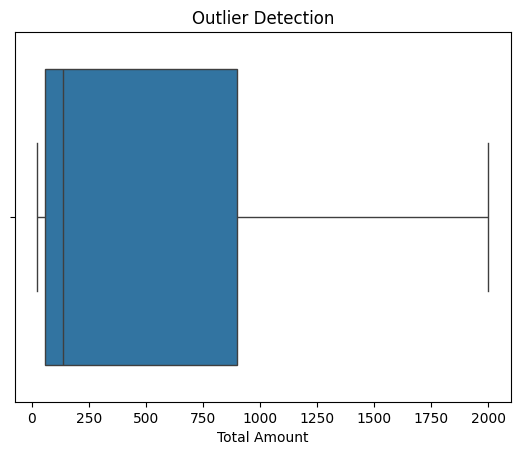

In [110]:
sns.boxplot(x=df['Total Amount'])
plt.title("Outlier Detection")
plt.show()

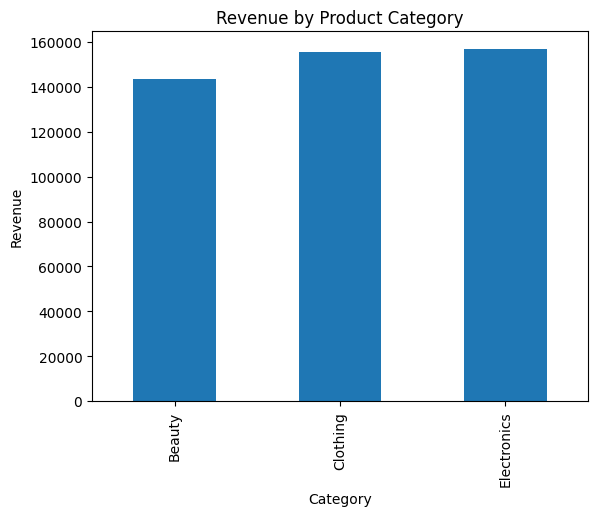

In [111]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

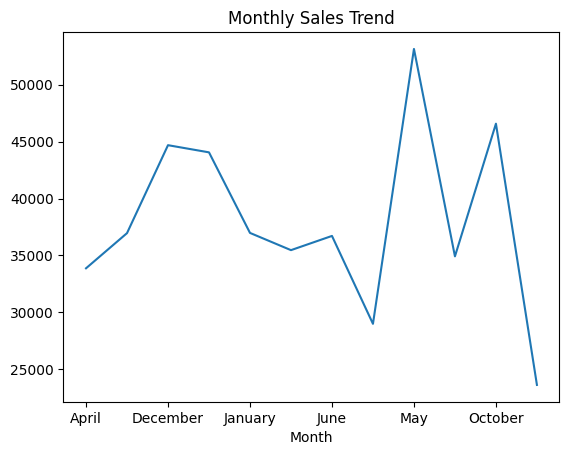

In [112]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()